In [77]:
# Import Packages

# General Tools
import numpy as np
import scipy as sp
import pandas as pd

# Machine Learning
from sklearn.datasets import fetch_openml
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.tree import DecisionTreeClassifier

# Typing
from typing import Callable, Dict, List, Optional, Set, Tuple, Union

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Parameters

#===========================Fill This===========================#
# 1. Set the options for the `criterion` parameter (Use all options).
# 2. Set the options for the `max_leaf_nodes` parameter.
lCriterion   = ['gini', 'entropy', 'log_loss'] #<! List
lMaxLeaf     = list(range(5, 11)) #<! List

In [13]:
# create the features matrix, in this trial we use the top 10 features
X_top_df = pd.read_csv('data/X_top_ten_feeat_to_Imax.csv')
X_top_arr = X_top_df.to_numpy(dtype=float)
X_top_arr = X_top_arr[:, 1:] # remove the first column

#for the current notebook we assign the feature matrix to mX
mX = X_top_arr

In [87]:
lfeatures_names= X_top_df.columns[1:]
lfeatures_names


Index(['f1_mass_PC1', 'f7_surface_shape_Mor_PC2', 'f6_volume_PC1',
       'f4_volume_PC1', 'f8_surface_shape_RDF_PC1', 'f5_volume_PC1',
       'f10_geometry_topology_PC1', 'f9_whim_PC1', 'f14_spdiam_PC1',
       'f13_p_vsa_logp_PC5'],
      dtype='str')

In [14]:
# create the Imax label vector
data_df = pd.read_csv('data/waka_dragon_merged.csv')
vImax = data_df['Imax'].values
vY = np.where(vImax >= 35.0, 1, 0) # we set the threshold to 35.0

In [41]:
data_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [40]:
vY

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,

In [19]:
print('The shape of the feature matrix is:', mX.shape)
print('The shape of the label vector is:', vY.shape)
vLabels, vCounts = np.unique(vY, return_counts=True)
print(f'labels: {vLabels}, counts: {vCounts}')

The shape of the feature matrix is: (312, 10)
The shape of the label vector is: (312,)
labels: [0 1], counts: [122 190]


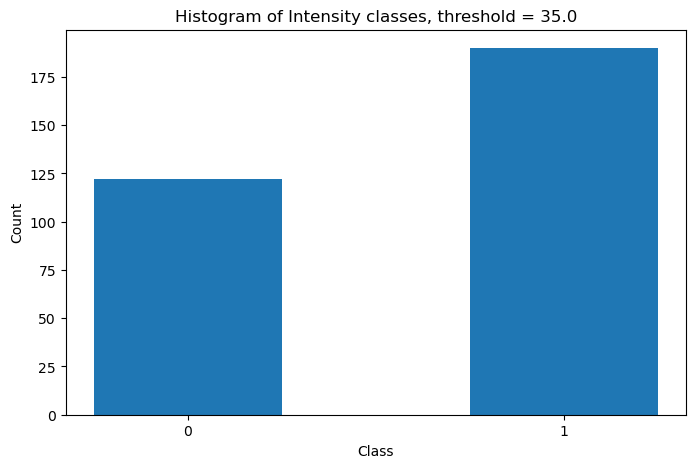

In [26]:
# plot the histofram of labels ()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(vLabels, vCounts, width=0.5)
ax.set_xlabel('Class')
ax.set_xticks(vLabels)
ax.set_ylabel('Count')
ax.set_title('Histogram of Intensity classes, threshold = 35.0')
plt.show()

In [30]:
# i want to check if there are any missing values in the feature matrix
print(f'Number of missing values in the feature matrix: {np.isnan(mX).sum()}')


Number of missing values in the feature matrix: 0


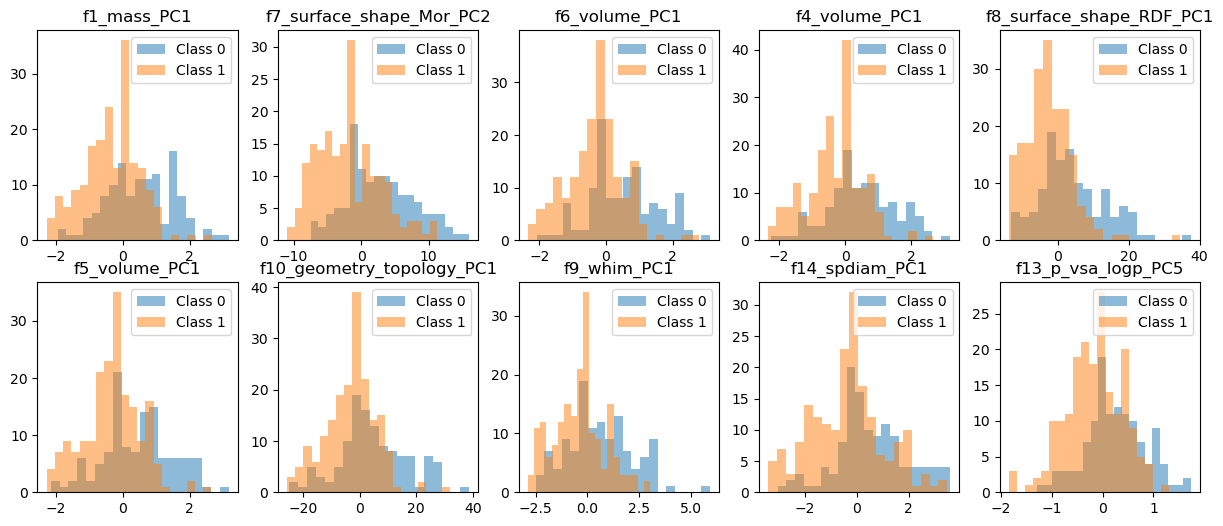

In [91]:
# i want to plot distribution of each feature in mX matrix for each class

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))

for feat_idx, axis in enumerate(ax.flat):
    axis.hist(mX[vY == 0, feat_idx], bins=20, alpha=0.5, label='Class 0')
    axis.hist(mX[vY == 1, feat_idx], bins=20, alpha=0.5, label='Class 1')
    axis.set_title(lfeatures_names[feat_idx])
    axis.legend()


plt.show()

In [52]:
numComb = len(lCriterion) * len(lMaxLeaf)

dict_results = {
    'criterion': [],
    'max_leaf_nodes': [],
    'f1_score': [0.0] * numComb,
    'accuracy': [0.0] * numComb,
    'precision': [0.0] * numComb,
    'recall': [0.0] * numComb
}

for i, criterion in enumerate(lCriterion):
    for j, max_leaf_nodes in enumerate(lMaxLeaf):
        dict_results['criterion'].append(criterion)
        dict_results['max_leaf_nodes'].append(max_leaf_nodes)

modelScores_df = pd.DataFrame(data=dict_results)
modelScores_df

,criterion,max_leaf_nodes,f1_score,accuracy,precision,recall
0,gini,5,0.0,0.0,0.0,0.0
1,gini,6,0.0,0.0,0.0,0.0
2,gini,7,0.0,0.0,0.0,0.0
3,gini,8,0.0,0.0,0.0,0.0
4,gini,9,0.0,0.0,0.0,0.0
5,gini,10,0.0,0.0,0.0,0.0
6,entropy,5,0.0,0.0,0.0,0.0
7,entropy,6,0.0,0.0,0.0,0.0
8,entropy,7,0.0,0.0,0.0,0.0
9,entropy,8,0.0,0.0,0.0,0.0


In [67]:
for i in range(numComb):
    paramCriterion = modelScores_df.loc[i, 'criterion']
    maxLeaf = modelScores_df.loc[i, 'max_leaf_nodes']

    print(f'Training model {i+1} from {numComb} with criterion: {paramCriterion} and max_leaf_nodes: {maxLeaf}')

    oDecTreeClf = DecisionTreeClassifier(criterion=paramCriterion, max_leaf_nodes=maxLeaf)
    vYPred = cross_val_predict(oDecTreeClf, mX, vY, cv=KFold(n_splits=mX.shape[0]))

    f1Score = f1_score(vY, vYPred)
    accuracy = accuracy_score(vY, vYPred)
    precision = precision_score(vY, vYPred)
    recall = recall_score(vY, vYPred)

    modelScores_df.loc[i, 'f1_score'] = f1Score
    modelScores_df.loc[i, 'accuracy'] = accuracy
    modelScores_df.loc[i, 'precision'] = precision
    modelScores_df.loc[i, 'recall'] = recall

    print(f'F1 score for model {i+1} is: {f1Score}')
    print(f'Accuracy for model {i+1} is: {accuracy}')
    print(f'Precision for model {i+1} is: {precision}')
    print(f'Recall for model {i+1} is: {recall}')

modelScores_df




Training model 1 from 18 with criterion: gini and max_leaf_nodes: 5
F1 score for model 1 is: 0.7937915742793792
Accuracy for model 1 is: 0.7019230769230769
Precision for model 1 is: 0.685823754789272
Recall for model 1 is: 0.9421052631578948
Training model 2 from 18 with criterion: gini and max_leaf_nodes: 6
F1 score for model 2 is: 0.8054298642533937
Accuracy for model 2 is: 0.7243589743589743
Precision for model 2 is: 0.7063492063492064
Recall for model 2 is: 0.9368421052631579
Training model 3 from 18 with criterion: gini and max_leaf_nodes: 7
F1 score for model 3 is: 0.8027210884353742
Accuracy for model 3 is: 0.7211538461538461
Precision for model 3 is: 0.7051792828685259
Recall for model 3 is: 0.9315789473684211
Training model 4 from 18 with criterion: gini and max_leaf_nodes: 8
F1 score for model 4 is: 0.7972665148063781
Accuracy for model 4 is: 0.7147435897435898
Precision for model 4 is: 0.7028112449799196
Recall for model 4 is: 0.9210526315789473
Training model 5 from 18 with

,criterion,max_leaf_nodes,f1_score,accuracy,precision,recall
0,gini,5,0.793792,0.701923,0.685824,0.942105
1,gini,6,0.805430,0.724359,0.706349,0.936842
2,gini,7,0.802721,0.721154,0.705179,0.931579
3,gini,8,0.797267,0.714744,0.702811,0.921053
4,gini,9,0.794521,0.711538,0.701613,0.915789
5,gini,10,0.799087,0.717949,0.705645,0.921053
6,entropy,5,0.796460,0.705128,0.687023,0.947368
7,entropy,6,0.796460,0.705128,0.687023,0.947368
8,entropy,7,0.810811,0.730769,0.708661,0.947368
9,entropy,8,0.808126,0.727564,0.707510,0.942105


In [69]:
modelScores_df.sort_values(by='f1_score', ascending=False).head(10)

,criterion,max_leaf_nodes,f1_score,accuracy,precision,recall
14,log_loss,7,0.810811,0.730769,0.708661,0.947368
8,entropy,7,0.810811,0.730769,0.708661,0.947368
15,log_loss,8,0.808126,0.727564,0.707510,0.942105
9,entropy,8,0.808126,0.727564,0.707510,0.942105
1,gini,6,0.805430,0.724359,0.706349,0.936842
17,log_loss,10,0.802721,0.721154,0.705179,0.931579
11,entropy,10,0.802721,0.721154,0.705179,0.931579
10,entropy,9,0.802721,0.721154,0.705179,0.931579
2,gini,7,0.802721,0.721154,0.705179,0.931579
16,log_loss,9,0.802721,0.721154,0.705179,0.931579


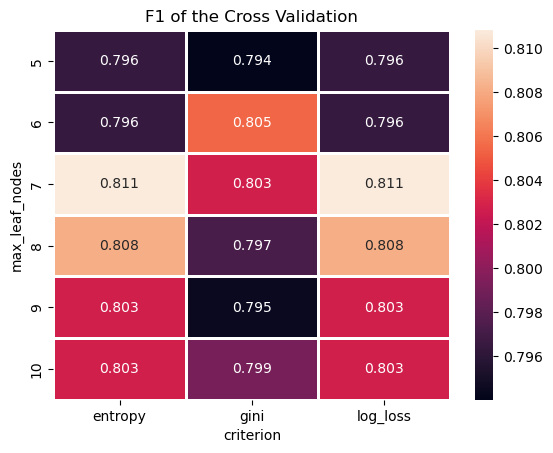

In [70]:
# i want to built  heat map of the modelScores_df

heat_df = modelScores_df.pivot(
    index='max_leaf_nodes', columns='criterion', values='f1_score'
)

hA = sns.heatmap(
    data=heat_df, annot=True, fmt='.3f', linewidths=1, robust=True
)
hA.set_title('F1 of the Cross Validation')
plt.show()

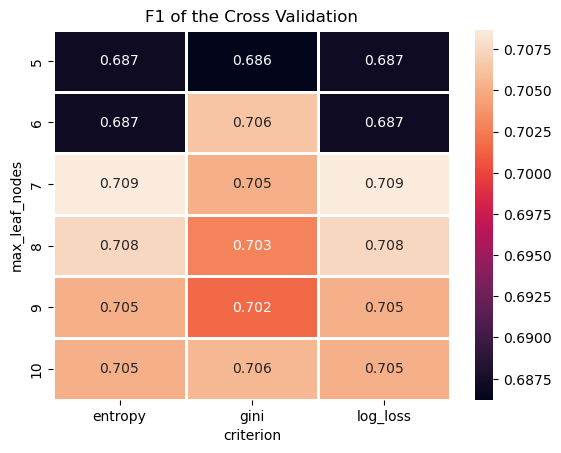

In [71]:
# i want to built  heat map of the modelScores_df

heat_df = modelScores_df.pivot(
    index='max_leaf_nodes', columns='criterion', values='precision'
)

hA = sns.heatmap(
    data=heat_df, annot=True, fmt='.3f', linewidths=1, robust=True
)
hA.set_title('F1 of the Cross Validation')
plt.show()

In [73]:
indArgmax = np.argmax(modelScores_df['f1_score'])
modelScores_df.loc[indArgmax]

criterion          entropy
max_leaf_nodes           7
f1_score          0.810811
accuracy          0.730769
precision         0.708661
recall            0.947368
Name: 8, dtype: object

In [74]:
optimalCriterion = modelScores_df.loc[indArgmax, 'criterion']
optimalMaxLeaf = modelScores_df.loc[indArgmax, 'max_leaf_nodes']
print(f'The optimal hyper-parameters are: criterion = {optimalCriterion} and max_leaf_nodes = {optimalMaxLeaf}')

The optimal hyper-parameters are: criterion = entropy and max_leaf_nodes = 7


In [75]:
# we define the model with the best found hyperparameters

oDecTreeClf = DecisionTreeClassifier(criterion=optimalCriterion, max_leaf_nodes=optimalMaxLeaf)
oDecTreeClf = oDecTreeClf.fit(mX, vY)
print(f'The accuracy of the model is: {oDecTreeClf.score(mX, vY):.2%}')
#oDecTreeClf.score(mX, vY)

The accuracy of the model is: 76.92%


In [80]:
# now, let's plot the confusion matrix
cm = confusion_matrix(vY, vYPred, ) #order (y_true, y_predict)

cm_df = pd.DataFrame(cm, index=['True 0', 'True 1'], columns=['Predicted 0', 'Predicted 1'])
cm_df




,Predicted 0,Predicted 1
True 0,48,74
True 1,13,177


In [81]:
tn, fp, fn, tp = confusion_matrix(vY, vYPred).ravel()

cm_named_df = pd.DataFrame(
    {'Count': [tn, fp, fn, tp]},
    index=['TN (0→0)', 'FP (0→1)', 'FN (1→0)', 'TP (1→1)']
)
cm_named_df

,Count
TN (0→0),48
FP (0→1),74
FN (1→0),13
TP (1→1),177


In [ ]:
print(f'Recall: {tp / (tp + fn):.2%}') # ability to detect true positives from all positives
print(f'Precision: {tp / (tp + fp):.2%}') # ability to detect true positives from all predicted positives
print(f'Accuracy: {(tp + tn) / (tp + tn + fp + fn):.2%}') # overall accuracy

Recall: 93.16%
Precision: 70.52%
Accuracy: 72.12%


In [84]:
# importance of fetures
vFeatureImportance = oDecTreeClf.feature_importances_
vFeatureImportance

array([0.44163916, 0.18460609, 0.        , 0.        , 0.09105922,
       0.        , 0.06568999, 0.        , 0.10558078, 0.11142476])

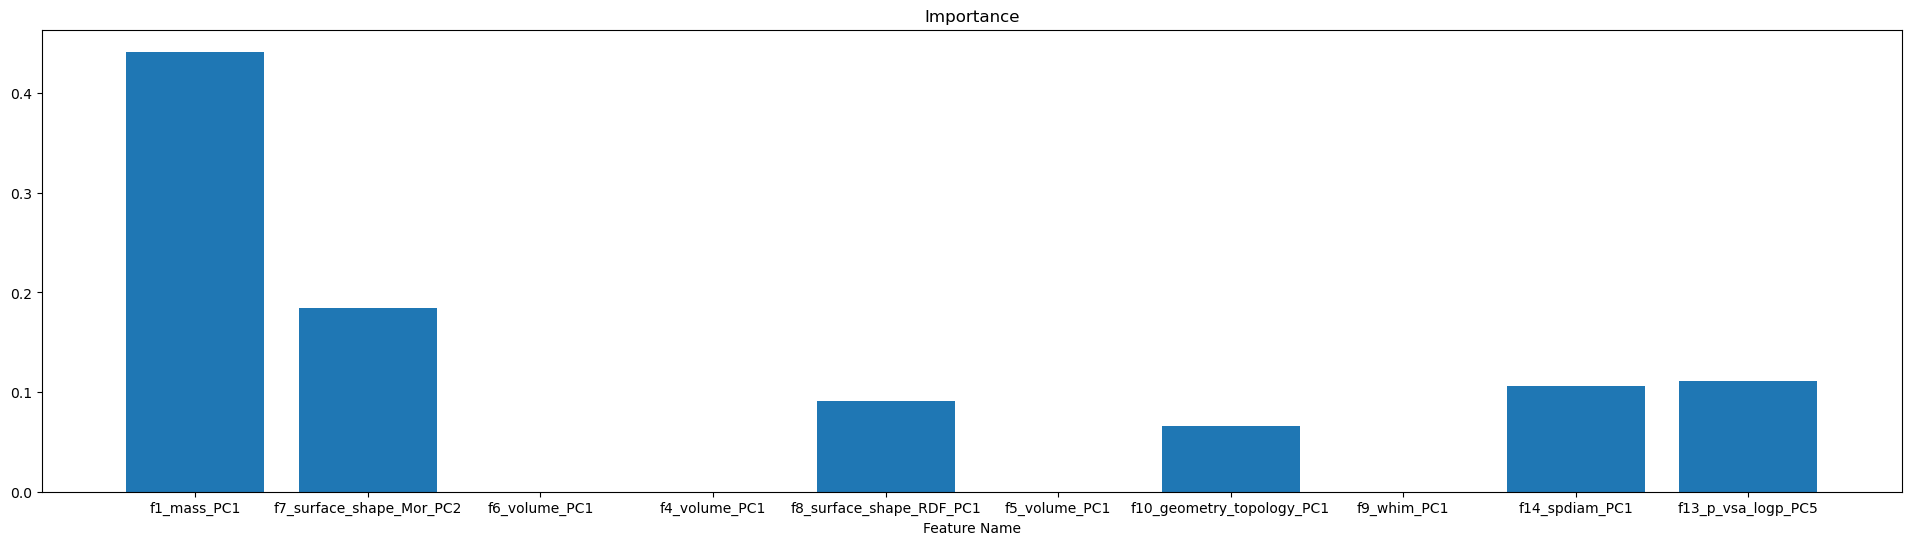

In [90]:
# Plot the Feature Importance

hF, hA = plt.subplots(figsize = (24, 6))
hA.bar(x = lfeatures_names, height = vFeatureImportance)
hA.set_title('Features Importance of the Model')
hA.set_xlabel('Feature Name')
hA.set_title('Importance');